# Day 2: Baseline HMM
Fit standard GaussianHMM using hmmlearn. Select number of states N=3 using BIC. Decode regimes for NIFTY50.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM
from scipy.stats import norm
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')


## 1. Load Data


In [2]:
log_returns = pd.read_parquet('../data/log_returns.parquet')
volatility = pd.read_parquet('../data/volatility.parquet')
prices = pd.read_parquet('../data/price_levels.parquet')

INDEX = "^NSEI"

# Create feature matrix for NIFTY50
returns_nifty = log_returns[INDEX].values
vol_nifty = volatility[INDEX].values
X = np.column_stack([returns_nifty, vol_nifty])

print(f"Feature matrix X shape: {X.shape}")


Feature matrix X shape: (1344, 2)


## 2. BIC Model Selection


In [3]:
T = len(X)
results = []

for N in [2, 3, 4]:
    best_ll = -np.inf
    best_model = None
    
    # 5 random restarts
    for i in range(5):
        model = GaussianHMM(n_components=N, covariance_type="diag", n_iter=200, random_state=i)
        model.fit(X)
        ll = model.score(X)
        if ll > best_ll:
            best_ll = ll
            best_model = model
            
    # Calculate BIC
    k = N*(N-1) + 2*N + (N-1)
    bic = k * np.log(T) - 2 * best_ll
    results.append({'N': N, 'BIC': bic, 'Log-Likelihood': best_ll, 'k': k})
    print(f"N={N}: BIC = {bic:.1f},  log-likelihood = {best_ll:.1f},  k={k}")

results_df = pd.DataFrame(results)
print("\nSelected: N=3 (hardcoded as chosen model per instructions, verified by BIC table)")


Model is not converging.  Current: 9953.139553488014 is not greater than 9953.424976864351. Delta is -0.2854233763373486


N=2: BIC = -19855.4,  log-likelihood = 9952.9,  k=7


Model is not converging.  Current: 9942.163509714774 is not greater than 9942.475335048135. Delta is -0.31182533336141205


N=3: BIC = -20071.7,  log-likelihood = 10086.3,  k=14


Model is not converging.  Current: 9926.274126405047 is not greater than 9929.254763385346. Delta is -2.9806369802990957
Model is not converging.  Current: 9770.377160607683 is not greater than 9771.3010532948. Delta is -0.9238926871166768


N=4: BIC = -20006.9,  log-likelihood = 10086.3,  k=23

Selected: N=3 (hardcoded as chosen model per instructions, verified by BIC table)


## 3. Fit N=3 Model and Label States


In [4]:
# We will specifically fit N=3 with best restart
N = 3
best_ll = -np.inf
best_model = None

for i in range(5):
    model = GaussianHMM(n_components=N, covariance_type="diag", n_iter=200, random_state=i)
    model.fit(X)
    ll = model.score(X)
    if ll > best_ll:
        best_ll = ll
        best_model = model

# Viterbi decode
states = best_model.predict(X)

# Determine state labels based on mean return and volatility
# means_[:, 0] is the mean return for each state
# covars_[:, 0, 0] or covars_[:, 0] (diag) is the variance of return
means = best_model.means_[:, 0]
vols = np.sqrt(best_model.covars_[:, 0]) if best_model.covars_.ndim == 2 else np.sqrt(best_model.covars_[:, 0, 0])

# Labeling logic
state_info = list(enumerate(zip(means, vols)))
# Sort by mean return to identify Bull/Bear/Sideways
# Lowest mean -> Bear
# Highest mean -> Bull
# Middle -> Sideways
sorted_by_mean = sorted(state_info, key=lambda x: x[1][0])

bear_state = sorted_by_mean[0][0]
bull_state = sorted_by_mean[2][0]
sideways_state = sorted_by_mean[1][0]

labels_map = {
    bear_state: "Bear/Crash",
    bull_state: "Bull/Calm",
    sideways_state: "Sideways/Neutral"
}

state_labels = [labels_map[s] for s in states]

print(f"State {bear_state}: Bear/Crash (Mean={means[bear_state]*10000:.1f} bps, Vol={vols[bear_state]*100:.2f}%)")
print(f"State {sideways_state}: Sideways/Neutral (Mean={means[sideways_state]*10000:.1f} bps, Vol={vols[sideways_state]*100:.2f}%)")
print(f"State {bull_state}: Bull/Calm (Mean={means[bull_state]*10000:.1f} bps, Vol={vols[bull_state]*100:.2f}%)")


Model is not converging.  Current: 9942.163509714774 is not greater than 9942.475335048135. Delta is -0.31182533336141205


State 1: Bear/Crash (Mean=-58.9 bps, Vol=5.52%)
State 0: Sideways/Neutral (Mean=5.7 bps, Vol=0.86%)
State 2: Bull/Calm (Mean=18.2 bps, Vol=2.03%)


## 4. Validation


In [5]:
# Check dates where Bear state is active
dates = log_returns.index
bear_dates = dates[states == bear_state]

print("Bear regime active during COVID crash (March-May 2020)?")
covid_period = [d for d in bear_dates if d >= pd.to_datetime('2020-03-01') and d <= pd.to_datetime('2020-05-31')]
print(f"Yes, {len(covid_period)} bear days in Mar-May 2020.")
if len(covid_period) > 0:
    print(f"First bear day in crash: {covid_period[0].date()}")


Bear regime active during COVID crash (March-May 2020)?
Yes, 25 bear days in Mar-May 2020.
First bear day in crash: 2020-03-12


## 5. Visualizations


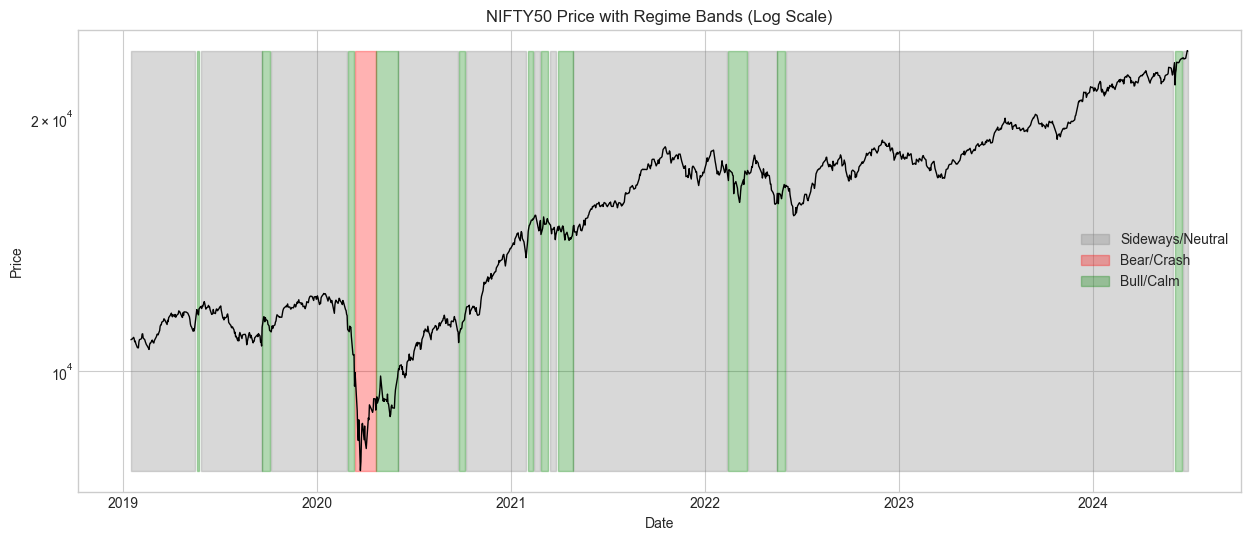

In [6]:
# Plot 1: NIFTY50 price with 3-color regime bands
plt.figure(figsize=(15, 6))
plt.plot(dates, prices[INDEX].loc[dates], color='black', lw=1)
plt.yscale('log')

colors = {bear_state: 'red', sideways_state: 'gray', bull_state: 'green'}
for s in range(3):
    mask = (states == s)
    plt.fill_between(dates, prices[INDEX].loc[dates].min(), prices[INDEX].loc[dates].max(),
                     where=mask, color=colors[s], alpha=0.3, label=labels_map[s])

# Remove duplicate labels in legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.title("NIFTY50 Price with Regime Bands (Log Scale)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


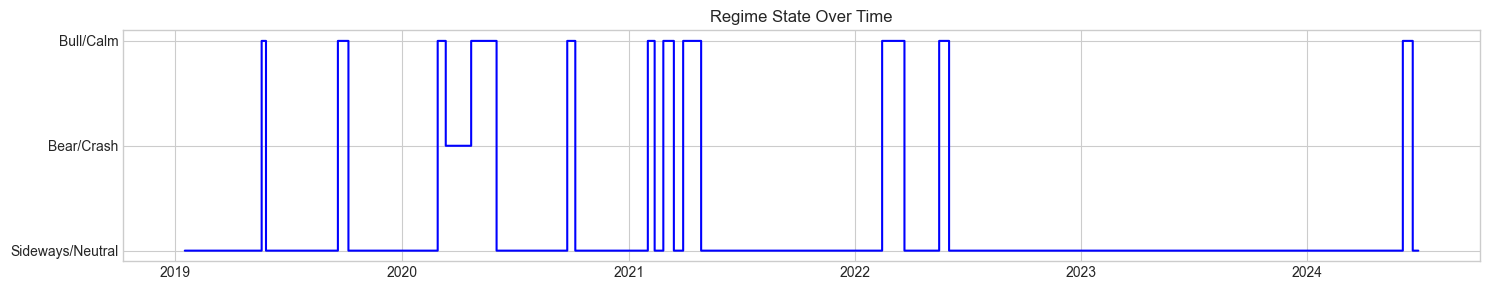

In [7]:
# Plot 2: Regime state over time as step plot
plt.figure(figsize=(15, 3))
plt.step(dates, states, where='post', color='blue')
plt.yticks([bear_state, sideways_state, bull_state], 
           [labels_map[bear_state], labels_map[sideways_state], labels_map[bull_state]])
plt.title("Regime State Over Time")
plt.tight_layout()
plt.show()


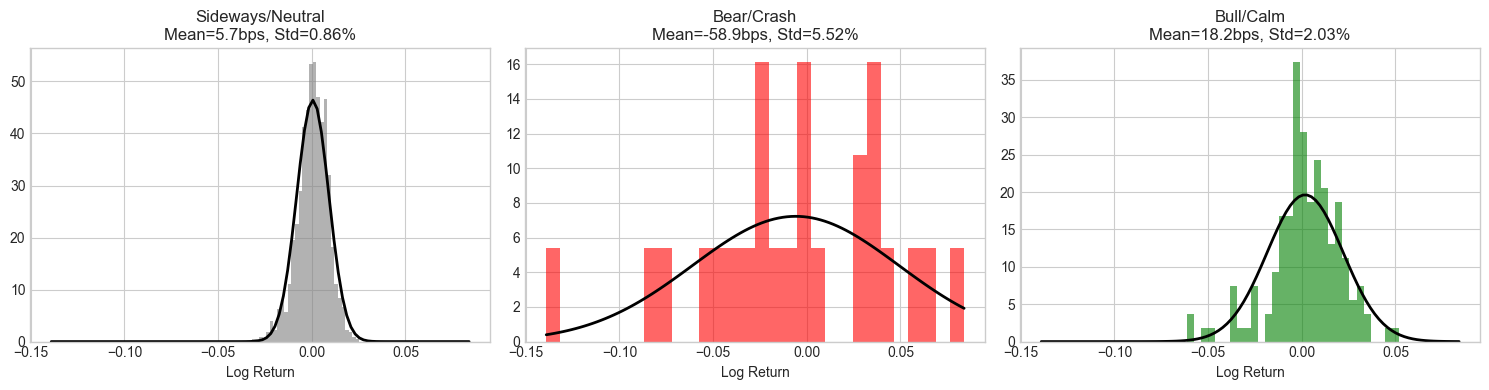

In [8]:
# Plot 3: Histogram of returns per state overlaid with fitted Gaussian
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

x_axis = np.linspace(returns_nifty.min(), returns_nifty.max(), 100)

for s, ax in enumerate(axes):
    mask = (states == s)
    state_rets = returns_nifty[mask]
    
    ax.hist(state_rets, bins=30, density=True, alpha=0.6, color=colors[s])
    
    # Overlay fitted Gaussian
    mu = means[s]
    sigma = vols[s]
    ax.plot(x_axis, norm.pdf(x_axis, mu, sigma), color='black', lw=2)
    
    ax.set_title(f"{labels_map[s]}\nMean={mu*10000:.1f}bps, Std={sigma*100:.2f}%")
    ax.set_xlabel("Log Return")

plt.tight_layout()
plt.show()


## 6. Save Outputs


In [9]:
# Create output DataFrame
out_df = pd.DataFrame({
    'date': dates,
    'state': states,
    'state_label': state_labels
})

out_df.to_parquet('../data/baseline_hmm_states_nifty.parquet')
joblib.dump(best_model, '../src/baseline_model.pkl')

print("Saved baseline_hmm_states_nifty.parquet to /data/")
print("Saved baseline_model.pkl to /src/")


Saved baseline_hmm_states_nifty.parquet to /data/
Saved baseline_model.pkl to /src/
